# Chocolate Sales Analysis (2022–2023)

## Project Overview

This project analyzes chocolate sales data from 2022–2023 to uncover business insights and build an interactive Power BI dashboard.

### Objectives

- Clean and prepare the dataset using Python (pandas)
- Perform exploratory data analysis (EDA)
- Identify trends in sales, products, countries, and salespersons
- Export a clean dataset for Power BI
- Build an interactive dashboard to support business decisions

## Phase 1 - Data Understanding

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
chocolate_sales = pd.read_csv("CSV's/Chocolate_Sales.csv")

In [3]:
chocolate_sales.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,12/11/2022,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,3/14/2023,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,12/21/2023,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,12/18/2023,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,8/18/2023,4.4,2.75,187.44,214,549.69


In [4]:
chocolate_sales.tail()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
199995,ORD-053460,70% Dark Bar,Australia,Retail,Beatriz Souza,5/27/2022,10.6,3.39,186.19,125,418.56
199996,ORD-010743,Truffle Gift Box,India,Wholesale,Arjun Mehta,9/6/2022,17.3,3.07,42.28,148,366.47
199997,ORD-049690,Salted Caramel Bar,Japan,Online,Arjun Mehta,6/16/2022,18.3,2.74,100.19,149,329.79
199998,ORD-189637,85% Dark Bar,Japan,Wholesale,Rohan Patel,10/14/2022,9.3,14.30,29.96,24,304.51
199999,ORD-061616,Mint Dark Bar,Australia,Retail,Hannah Müller,1/25/2022,7.2,3.01,270.86,131,366.91


In [5]:
# Dataset dimensions
chocolate_sales.shape

(200000, 11)

In [6]:
chocolate_sales.columns

Index(['Order_ID', 'Product', 'Country', 'Channel', 'Salesperson',
       'Order_Date', 'Discount_Pct', 'Price_per_Box', 'Marketing_Spend',
       'Boxes_Shipped', 'Amount'],
      dtype='object')

In [7]:
# Data types
chocolate_sales.dtypes

Order_ID            object
Product             object
Country             object
Channel             object
Salesperson         object
Order_Date          object
Discount_Pct       float64
Price_per_Box      float64
Marketing_Spend    float64
Boxes_Shipped        int64
Amount              object
dtype: object

In [8]:
chocolate_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


In [9]:
chocolate_sales.describe()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


In [10]:
# Missing values
chocolate_sales.isnull().sum()

Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [11]:
chocolate_sales.duplicated().sum()

np.int64(0)

In [12]:
chocolate_sales.nunique()

Order_ID           200000
Product                12
Country                 5
Channel                 3
Salesperson            25
Order_Date           1134
Discount_Pct         2517
Price_per_Box        1381
Marketing_Spend     27319
Boxes_Shipped        1521
Amount              85605
dtype: int64

In [13]:
chocolate_sales.Country.unique()

array(['Australia', 'Japan', 'Germany', 'Brazil', 'India'], dtype=object)

In [14]:
chocolate_sales[chocolate_sales.isnull().any(axis=1)]

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
72,ORD-027870,Pralines Gift Box,Brazil,Retail,Yuki Sato,3/3/2022,7.1,NaN,84.81,162,494.46
81,ORD-134997,Choco Coins Bag,Japan,Wholesale,Rohan Patel,3/26/2022,7.7,NaN,147.42,224,728.89
174,ORD-085354,70% Dark Bar,Australia,Online,James Carter,1/1/2022,17.5,NaN,33.78,48,121.91
180,ORD-104088,Truffle Gift Box,Brazil,Retail,Emily Clarke,NaN,15.8,3.61,143.87,301,836.33
190,ORD-128088,Pralines Gift Box,Australia,Retail,Priya Sharma,6/11/2022,NaN,2.88,66.11,199,552.78
...,...,...,...,...,...,...,...,...,...,...,...
199594,ORD-099370,Almond Crunch Bar,Australia,Retail,Yuki Sato,NaN,13.4,NaN,53.41,170,357.01
199604,ORD-144195,Milk Classic Bar,Germany,Retail,Priya Sharma,2/25/2022,10.7,NaN,96.06,103,307.29
199731,ORD-033532,70% Dark Bar,Australia,Wholesale,Rafael Oliveira,NaN,25.4,3.01,66.00,159,368.42
199750,ORD-025224,70% Dark Bar,Brazil,Online,Emily Clarke,12/21/2022,NaN,3.10,53.61,140,406.76


In [15]:
# Convert datatype into datetime64[ns] for order_date column
chocolate_sales.Order_Date  = pd.to_datetime(chocolate_sales.Order_Date, format="mixed")

In [16]:
chocolate_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Order_ID         200000 non-null  object        
 1   Product          200000 non-null  object        
 2   Country          200000 non-null  object        
 3   Channel          200000 non-null  object        
 4   Salesperson      200000 non-null  object        
 5   Order_Date       199563 non-null  datetime64[ns]
 6   Discount_Pct     199511 non-null  float64       
 7   Price_per_Box    199543 non-null  float64       
 8   Marketing_Spend  199539 non-null  float64       
 9   Boxes_Shipped    200000 non-null  int64         
 10  Amount           200000 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 16.8+ MB


In [18]:
# Drop all null values
chocolate_sales = chocolate_sales.dropna()

In [19]:
chocolate_sales.isnull().sum()

Order_ID           0
Product            0
Country            0
Channel            0
Salesperson        0
Order_Date         0
Discount_Pct       0
Price_per_Box      0
Marketing_Spend    0
Boxes_Shipped      0
Amount             0
dtype: int64

In [20]:
chocolate_sales.shape

(198397, 11)

## Handling Missing Values

The dataset contained missing values in Order_Date, Discount_Pct, Price_per_Box, and Marketing_Spend. Only 1,603 out of 200,000 records (0.80%) were affected. Because the proportion was very small, the incomplete records were removed using dropna(). This preserved over 99% of the dataset while avoiding assumptions that could bias the analysis.

In [21]:
print(chocolate_sales.Amount.dtype)
print(chocolate_sales.Amount.apply(type).value_counts())

object
Amount
<class 'str'>    198397
Name: count, dtype: int64


In [25]:
chocolate_sales.Amount = (
    chocolate_sales.Amount.astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False).astype(float)
)

In [26]:
print(chocolate_sales.Amount.dtype)

float64


### Converting the `Amount` Column to a Numeric Data Type

The `Amount` column was initially stored as an `object` instead of a numeric data type, which prevented mathematical operations such as calculating total revenue and average order value. The column was converted to a numeric (`float64`) data type to enable accurate calculations, statistical analysis, and data visualization throughout the project.

# Exploratory Data Analysis (EDA)

### 1) Overall Performance

In [27]:
total_revenue = chocolate_sales.Amount.sum()
print(f"Total Revenue: ${total_revenue:,}")

Total Revenue: $101,746,622.98


In [28]:
average_order_value = chocolate_sales.Amount.mean()
print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $512.84


In [29]:
total_orders = chocolate_sales.Amount.nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 83,130


In [30]:
total_boxes = chocolate_sales.Boxes_Shipped.sum()
print(f"Total Boxes Shipped: {total_boxes:,}")

Total Boxes Shipped: 27,691,275


#### Business Insight:
The company generated $101,746,622.98 in total revenue from 200,000 orders. The total number of boxes shipped was 27,691,275. These KPIs provide a high-level overview of business performance and will serve as the primary metrics displayed on the executive dashboard.

### 2) Revenue by Product

In [31]:
product_sales = (
    chocolate_sales.groupby('Product', as_index=False)['Amount']
    .sum().sort_values('Amount', ascending=False)
)
product_sales

,Product,Amount
0,70% Dark Bar,26159678.68
7,Mixed Assortment Box,19405032.16
10,Truffle Gift Box,19237789.55
5,Milk Classic Bar,6196107.09
2,Almond Crunch Bar,5732351.02
8,Pralines Gift Box,5708907.99
3,Choco Coins Bag,4739414.39
6,Mint Dark Bar,3488813.73
11,White Choco Bar,3196881.88
1,85% Dark Bar,2944074.50


#### Visualization

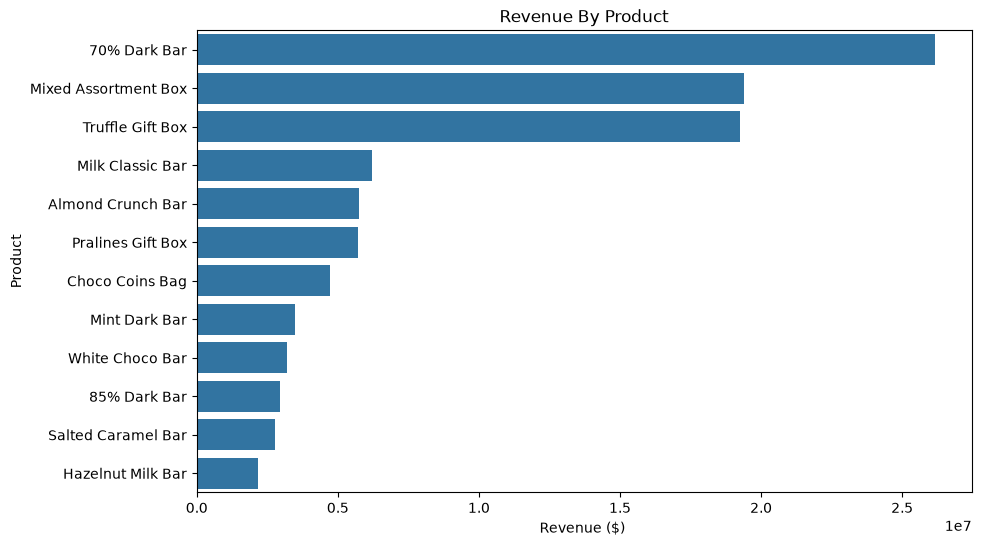

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x=product_sales.Amount, y=product_sales.Product)

plt.title("Revenue By Product")
plt.xlabel("Revenue ($) ")
plt.show()

####  Business Insight:
70% Dark Bar generated the highest revenue, followed by Mixed Assortment Box and Truffle Gift Box. These products appear to be the company's strongest revenue drivers and should remain a priority for sales and marketing efforts.

### 3) Revenue by Country

In [33]:
country_sales = chocolate_sales.groupby('Country', as_index=False)['Amount'].sum()
country_sales

,Country,Amount
0,Australia,42091134.12
1,Brazil,36347661.46
2,Germany,11256585.62
3,India,6441175.05
4,Japan,5610066.73


#### Visualization

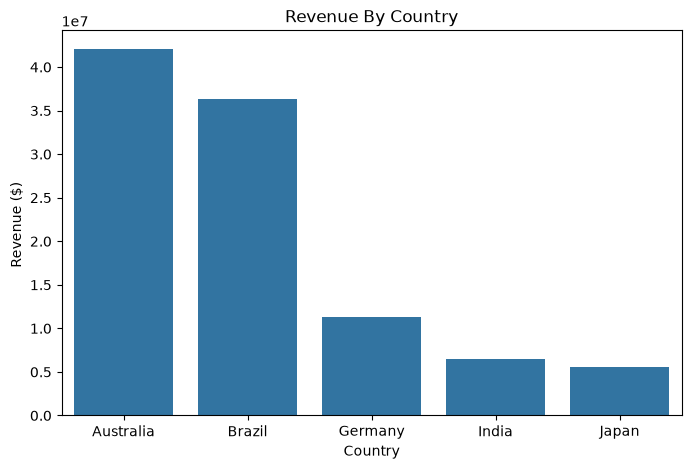

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x=country_sales.Country, y=country_sales.Amount)
plt.title("Revenue By Country")
plt.xlabel("Country")
plt.ylabel("Revenue ($) ")
plt.show()

#### Business Insight: 
Australia contributed the highest revenue, while Japan recorded the lowest. This suggests stronger market performance in Australia and potential opportunities for growth in Japan.

### 4) Revenue by Sales Channel

In [68]:
channel_sales = (
    chocolate_sales.groupby('Channel', as_index=False)['Amount']
    .sum().sort_values('Amount', ascending=False)
)
channel_sales

,Channel,Amount
1,Retail,53353980.24
2,Wholesale,37183027.07
0,Online,11209615.67


#### Visualization

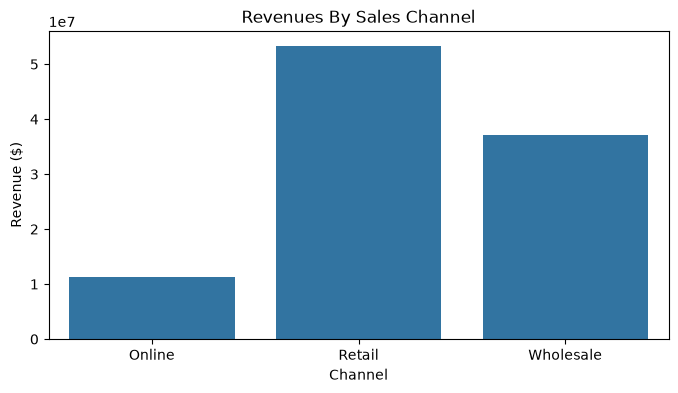

In [36]:
plt.figure(figsize=(8,4))
sns.barplot(x=channel_sales.Channel, y=channel_sales.Amount)
plt.title("Revenues By Sales Channel")
plt.ylabel("Revenue ($)")
plt.show()

#### Business Insight:
Retail generated the highest revenue among all sales channels, making it the company's strongest sales channel during the analysis period. Wholesale ranked second, while Online contributed the lowest revenue. This distribution suggests that the business relies heavily on traditional sales channels, while the online channel may present an opportunity for further investment and growth.

### 5) Top 10 Salespeople

In [69]:
top_sales = (
    chocolate_sales.groupby('Salesperson', as_index=False)['Amount']
    .sum().head(10).sort_values('Amount', ascending=False)
)
top_sales

,Salesperson,Amount
1,Arjun Mehta,34411250.38
6,Emily Clarke,9044538.16
7,Felix Becker,2431026.07
3,Camila Santos,1917113.33
2,Beatriz Souza,1724537.22
9,Hannah Müller,1342847.09
5,Daniel Weber,1018609.11
8,Gabriel Silva,1015685.48
4,Carlos Mendez,801575.05
0,Ananya Gupta,763446.30


#### Visualization

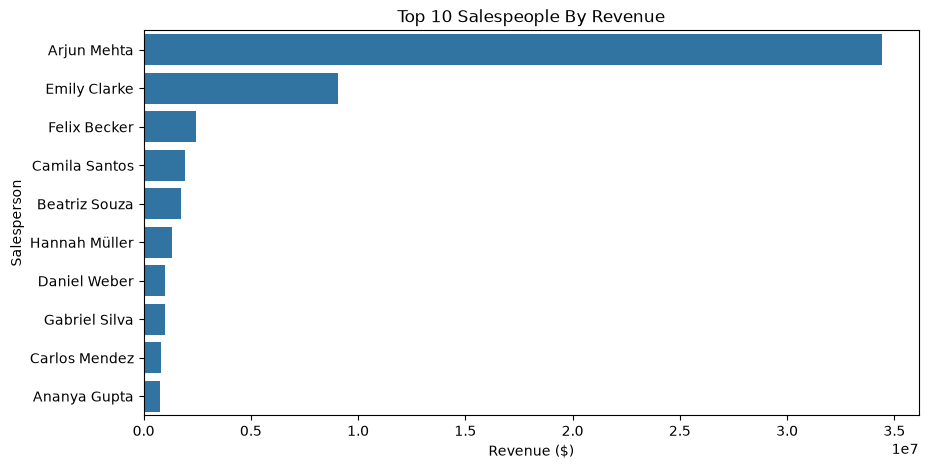

In [71]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_sales.Amount, y=top_sales.Salesperson)
plt.title("Top 10 Salespeople By Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Salesperson")
plt.show()

### 6) Monthly Revenue Trend

In [47]:
# Additional columns to view revenue trend
chocolate_sales['Year'] = chocolate_sales['Order_Date'].dt.year
chocolate_sales['Month'] = chocolate_sales['Order_Date'].dt.month
chocolate_sales

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount,Year,Month
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31,2022,12
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91,2023,3
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.70,2023,12
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27,2023,12
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69,2023,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,ORD-053460,70% Dark Bar,Australia,Retail,Beatriz Souza,2022-05-27,10.6,3.39,186.19,125,418.56,2022,5
199996,ORD-010743,Truffle Gift Box,India,Wholesale,Arjun Mehta,2022-09-06,17.3,3.07,42.28,148,366.47,2022,9
199997,ORD-049690,Salted Caramel Bar,Japan,Online,Arjun Mehta,2022-06-16,18.3,2.74,100.19,149,329.79,2022,6
199998,ORD-189637,85% Dark Bar,Japan,Wholesale,Rohan Patel,2022-10-14,9.3,14.30,29.96,24,304.51,2022,10


In [70]:
monthly_sales = (
    chocolate_sales.groupby('Month', as_index=False)['Amount']
    .sum().sort_values('Amount', ascending=False)
)
monthly_sales

,Month,Amount
11,12,11061194.40
10,11,9733480.95
0,1,9627906.14
9,10,8752885.80
8,9,8063780.21
1,2,8053012.83
7,8,8047737.07
2,3,7974719.63
4,5,7886635.10
3,4,7702463.86


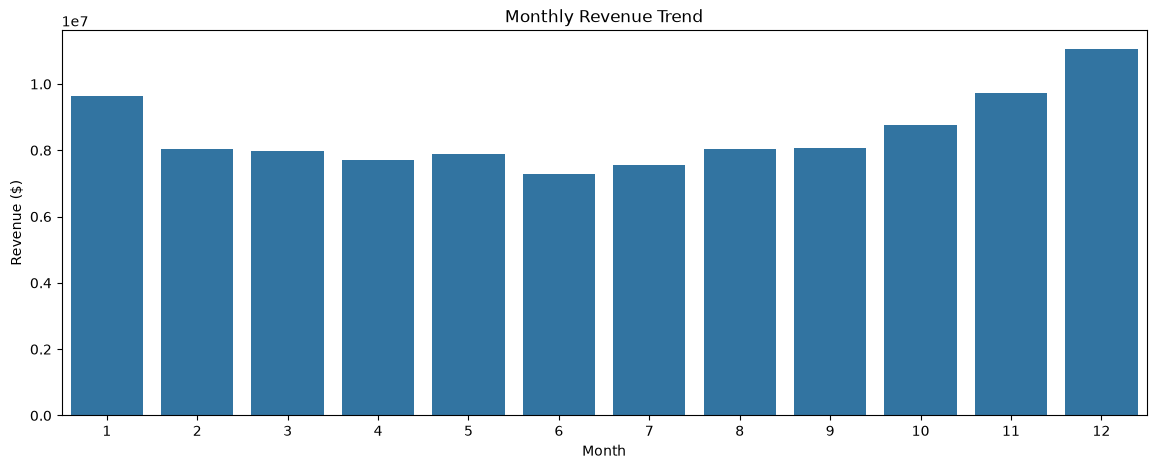

In [63]:
plt.figure(figsize=(14,5))
sns.barplot(x=monthly_sales.Month, y=monthly_sales.Amount)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()

#### Business Insight

December recorded the highest monthly revenue, followed by November, and January. June had the lowest revenue.

The results suggest that sales fluctuate throughout the year, with stronger performance towards the end of the year. This pattern can help the business plan inventory, marketing campaigns, and sales strategies more effectively.

### 7) Revenue Distribution

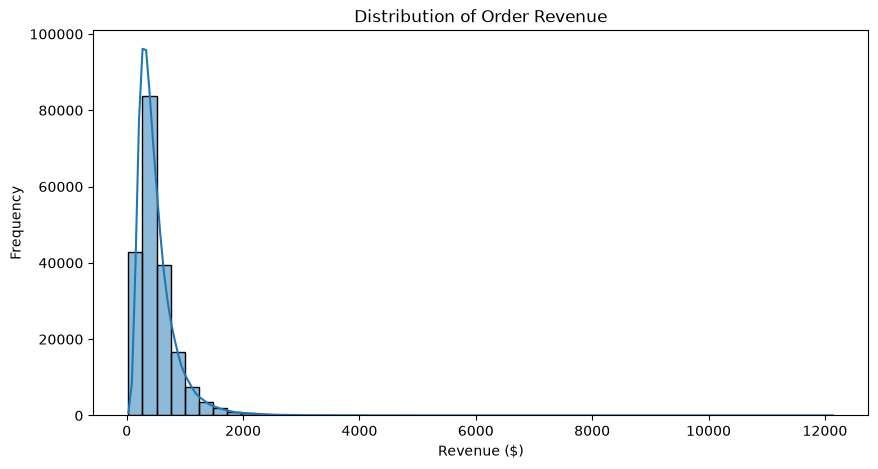

In [79]:
plt.figure(figsize=(10,5))
sns.histplot(chocolate_sales.Amount, bins=50, kde=True)
plt.title("Distribution of Order Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Frequency")
plt.show()

#### Business Insight
The distribution of order revenue is positively skewed, with most orders generating relatively low to moderate revenue. As order revenue increases, the number of orders decreases significantly, resulting in a long tail of high-value orders.
This indicates that the company's sales are primarily driven by a large number of smaller transactions, while a smaller number of high-value orders contribute to the overall revenue.

### 8) Marketing Spend vs Revenue

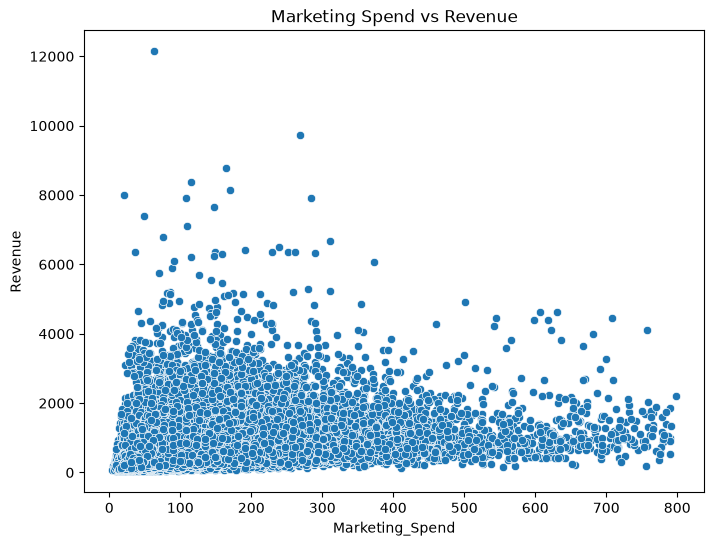

In [84]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=chocolate_sales.Marketing_Spend, y=chocolate_sales.Amount)
plt.title("Marketing Spend vs Revenue")
plt.ylabel("Revenue")
plt.show()

In [85]:
# Correlation coefficient
chocolate_sales.Marketing_Spend.corr(chocolate_sales.Amount)

np.float64(0.37264357756719596)

#### Business Insight
The scatter plot and correlation analysis indicate a moderate positive relationship between marketing spend and revenue (correlation = 0.373). While revenue generally tends to increase as marketing spend increases, the relationship is not strong, and there is considerable variation in revenue across different levels of marketing spend.
This suggests that marketing spend contributes to revenue generation, but other factors such as product type, sales channel, pricing, and customer demand also influence sales performance.

In [86]:
chocolate_sales.to_csv("Chocolate_Sales_Cleaned.csv", index=False)

### Objective

The cleaned dataset was exported for use in Power BI. Exporting the processed data ensures that the dashboard is built on a consistent and analysis-ready dataset without repeating the cleaning steps.